In [1]:
# UK Car Price Prediction - Feature Engineering
## Task 3 - Data Preprocessing & Feature Analysis
### Label Encoding | Correlation Analysis | Feature Importance

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('uk_car_data.csv')
print("=" * 55)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")
print(f"\nFirst 5 rows:")
print(df.head().to_string(index=False))

  DATASET LOADED SUCCESSFULLY
  Rows    : 300
  Columns : 9

First 5 rows:
   Brand   Model  Year Fuel_Type Transmission  Engine_Size  Mileage  Owners  Price_GBP
Vauxhall   Mokka  2022    Petrol    Automatic          1.6    55886       1    14500.0
  Nissan X-Trail  2013    Petrol    Automatic          1.6     1769       2    10600.0
  Toyota   Yaris  2021    Petrol       Manual          2.0    72932       1    22100.0
 Hyundai    Kona  2021    Petrol       Manual          2.5    36773       1    19300.0
Mercedes C Class  2012    Hybrid    Automatic          1.0    81038       1    24000.0


In [4]:
# Age feature
df['Age'] = 2024 - df['Year']

print("=" * 55)
print("  FEATURE ENGINEERING")
print("=" * 55)
print(f"  New Feature : Age = 2024 - Year")
print(f"  Age Range   : {df['Age'].min()} - {df['Age'].max()} years")
print(f"\n  Year vs Age Sample:")
print(df[['Brand','Year','Age','Price_GBP']].head(10).to_string(index=False))

  FEATURE ENGINEERING
  New Feature : Age = 2024 - Year
  Age Range   : 1 - 14 years

  Year vs Age Sample:
     Brand  Year  Age  Price_GBP
  Vauxhall  2022    2    14500.0
    Nissan  2013   11    10600.0
    Toyota  2021    3    22100.0
   Hyundai  2021    3    19300.0
  Mercedes  2012   12    24000.0
Volkswagen  2018    6    16600.0
    Nissan  2023    1    20800.0
   Hyundai  2015    9     8300.0
    Nissan  2018    6    17500.0
   Hyundai  2021    3    17600.0


In [5]:
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
le_fuel  = LabelEncoder()
le_trans = LabelEncoder()

df['Brand_Enc']        = le_brand.fit_transform(df['Brand'])
df['Fuel_Type_Enc']    = le_fuel.fit_transform(df['Fuel_Type'])
df['Transmission_Enc'] = le_trans.fit_transform(df['Transmission'])

print("=" * 55)
print("  LABEL ENCODING")
print("=" * 55)
print("\n  Brand Encoding:")
for original, encoded in zip(le_brand.classes_,
                              range(len(le_brand.classes_))):
    print(f"    {original:<15} -> {encoded}")

print("\n  Fuel Type Encoding:")
for original, encoded in zip(le_fuel.classes_,
                              range(len(le_fuel.classes_))):
    print(f"    {original:<15} -> {encoded}")

print("\n  Transmission Encoding:")
for original, encoded in zip(le_trans.classes_,
                              range(len(le_trans.classes_))):
    print(f"    {original:<15} -> {encoded}")

print("\n  Encoded Dataset Sample:")
print(df[['Brand','Brand_Enc','Fuel_Type',
          'Fuel_Type_Enc','Transmission',
          'Transmission_Enc']].head(8).to_string(index=False))

  LABEL ENCODING

  Brand Encoding:
    Audi            -> 0
    BMW             -> 1
    Ford            -> 2
    Honda           -> 3
    Hyundai         -> 4
    Mercedes        -> 5
    Nissan          -> 6
    Toyota          -> 7
    Vauxhall        -> 8
    Volkswagen      -> 9

  Fuel Type Encoding:
    Diesel          -> 0
    Electric        -> 1
    Hybrid          -> 2
    Petrol          -> 3

  Transmission Encoding:
    Automatic       -> 0
    Manual          -> 1

  Encoded Dataset Sample:
     Brand  Brand_Enc Fuel_Type  Fuel_Type_Enc Transmission  Transmission_Enc
  Vauxhall          8    Petrol              3    Automatic                 0
    Nissan          6    Petrol              3    Automatic                 0
    Toyota          7    Petrol              3       Manual                 1
   Hyundai          4    Petrol              3       Manual                 1
  Mercedes          5    Hybrid              2    Automatic                 0
Volkswagen          

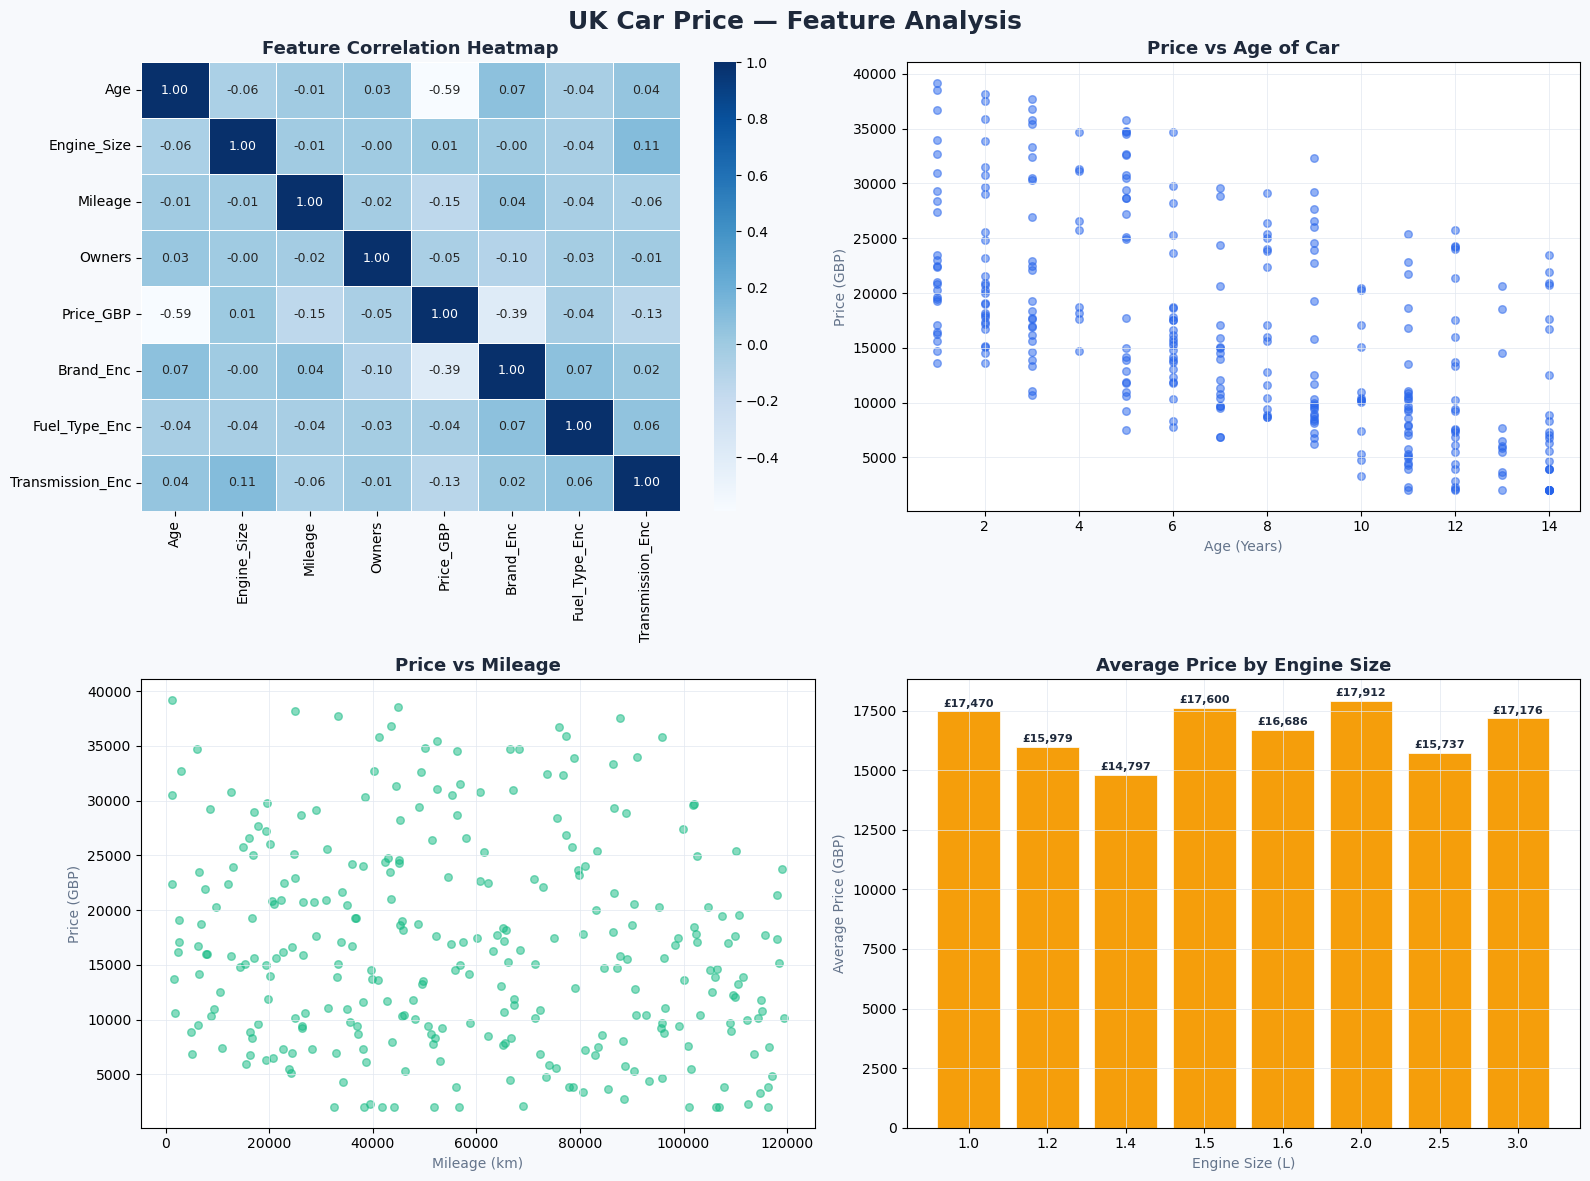

  FEATURE ANALYSIS COMPLETE

  Features used in ML Model:
    - Age
    - Engine_Size
    - Mileage
    - Owners
    - Brand_Enc
    - Fuel_Type_Enc
    - Transmission_Enc

  Target Variable : Price_GBP

  Key Correlations with Price:
    Engine_Size          : 0.01
    Fuel_Type_Enc        : -0.04
    Owners               : -0.05
    Transmission_Enc     : -0.13
    Mileage              : -0.15
    Brand_Enc            : -0.39
    Age                  : -0.59
  FILE 3 — FEATURE ENGINEERING COMPLETE


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#F7F9FC')
fig.suptitle('UK Car Price — Feature Analysis',
             fontsize=18, fontweight='bold', color='#1E293B')

# Chart 1 — Correlation Heatmap
ax1 = axes[0, 0]
ax1.set_facecolor('#FFFFFF')
numeric_cols = df[['Age','Engine_Size','Mileage',
                   'Owners','Price_GBP',
                   'Brand_Enc','Fuel_Type_Enc',
                   'Transmission_Enc']]
corr = numeric_cols.corr().round(2)
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax1,
            cmap='Blues', linewidths=0.5,
            annot_kws={'size': 9})
ax1.set_title('Feature Correlation Heatmap',
              fontweight='bold', color='#1E293B', fontsize=13)

# Chart 2 — Price vs Age
ax2 = axes[0, 1]
ax2.set_facecolor('#FFFFFF')
ax2.scatter(df['Age'], df['Price_GBP'],
            color='#2563EB', alpha=0.5, s=30)
ax2.set_title('Price vs Age of Car',
              fontweight='bold', color='#1E293B', fontsize=13)
ax2.set_xlabel('Age (Years)', color='#64748B')
ax2.set_ylabel('Price (GBP)', color='#64748B')
ax2.grid(True, color='#E2E8F0', linewidth=0.5)

# Chart 3 — Price vs Mileage
ax3 = axes[1, 0]
ax3.set_facecolor('#FFFFFF')
ax3.scatter(df['Mileage'], df['Price_GBP'],
            color='#10B981', alpha=0.5, s=30)
ax3.set_title('Price vs Mileage',
              fontweight='bold', color='#1E293B', fontsize=13)
ax3.set_xlabel('Mileage (km)', color='#64748B')
ax3.set_ylabel('Price (GBP)', color='#64748B')
ax3.grid(True, color='#E2E8F0', linewidth=0.5)

# Chart 4 — Price vs Engine Size
ax4 = axes[1, 1]
ax4.set_facecolor('#FFFFFF')
engine_avg = df.groupby('Engine_Size')['Price_GBP'].mean().sort_index()
ax4.bar(engine_avg.index.astype(str), engine_avg.values,
        color='#F59E0B', edgecolor='white', linewidth=0.5)
ax4.set_title('Average Price by Engine Size',
              fontweight='bold', color='#1E293B', fontsize=13)
ax4.set_xlabel('Engine Size (L)', color='#64748B')
ax4.set_ylabel('Average Price (GBP)', color='#64748B')
ax4.grid(True, color='#E2E8F0', linewidth=0.5)
for i, (eng, val) in enumerate(zip(engine_avg.index, engine_avg.values)):
    ax4.text(i, val + 200, f'£{val:,.0f}',
             ha='center', fontsize=8,
             fontweight='bold', color='#1E293B')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F7F9FC')
plt.show()

print("=" * 55)
print("  FEATURE ANALYSIS COMPLETE")
print("=" * 55)
print("\n  Features used in ML Model:")
features = ['Age', 'Engine_Size', 'Mileage', 'Owners',
            'Brand_Enc', 'Fuel_Type_Enc', 'Transmission_Enc']
for f in features:
    print(f"    - {f}")
print("\n  Target Variable : Price_GBP")
print("\n  Key Correlations with Price:")
corr_price = corr['Price_GBP'].drop('Price_GBP').sort_values(
    ascending=False)
for feat, val in corr_price.items():
    print(f"    {feat:<20} : {val:.2f}")
print("=" * 55)
print("  FILE 3 — FEATURE ENGINEERING COMPLETE")
print("=" * 55)